## Импорты

In [80]:
import pandas as pd
import numpy as np
import torch
import os

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils
import torch.utils.data

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# ROOT_DIR = ".\\data\\data_test.csv"
# ROOT_DIR = ".\\data\\data_scaled.csv"


ROOT_DIR = ".\\data\\tests__hypotesys\\data_experiment_12_scaled.csv"
folder = '.\\data\\tests__hypotesys\\Results_experiment_14\\' #

# ROOT_DIR = ".\\data\\tests__hypotesys\\data_367_scaled.csv"
# folder = '.\\data\\tests__hypotesys\\Results367_experiment9\\' # Папка для выгрузки результатов



# folder = 'C:\\Users\\faire\\OneDrive\\Desktop\\SVAI\\gtm-pa-main\\gtm-pa-main\\f_prohodskiy\\Contract_3\\Task_2\\reg\\'

In [ ]:
def check_count_soils(d, border):
    suma = 0
    for i in range(len(d)):
        if d[i][1].shape[0] > border:
            print(d[i][2], d[i][1].shape[0])
            suma += d[i][1].shape[0]
    print('Всего: ',suma)


def check_count_soils_test(d):
    # Создаём пустой датафрейм с нужными столбцами
    test = pd.DataFrame(columns=['soil', 'rows', 'DM'])
    
    # Множество допустимых значений почв (для быстрой проверки)
    soil_stack = {
        '1111112222222222', '1111113333322222', '1111114442222222',
        '1111122222222222', '1111122222333222', '1111144422222222',
        '1114422222322222', '3364444555550000'
    }
    
    suma = 0
    new_data = []
    
    for item in d:
        soil_code = str(item[2])
        if soil_code in soil_stack:
            # Количество строк в массиве/датафрейме
            row_count = item[1].shape[0]
            DM_count = item[1]['Mark_num'].unique().shape[0]
            print(soil_code, row_count)
            
            # Добавляем данные в список (временное накопление)
            new_data.append({'soil': soil_code, 'rows': row_count, 'DM': DM_count})
            suma += row_count
    
    if new_data:
        test = pd.DataFrame(new_data)
    
    print(suma)
    return test

## Архитектура модели



In [93]:
# class NeuralNet(nn.Module):

#     def __init__(self):

#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(33,96), # 6_10
#             nn.BatchNorm1d(96),
#             nn.ReLU(),
            
#             nn.Linear(96,64),
#             nn.ReLU(),
        
#             nn.Linear(64,32),
#             nn.ReLU(),

#             nn.Linear(32,1)
#         )

#     def forward(self, x):
#         return self.net(x)



class NeuralNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(33,32), # 6_10
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32,1)
        )

    def forward(self, x):
        return self.net(x)

# class NeuralNet(nn.Module):

#     def __init__(self):

#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(33,32), # 6_10
#             nn.ReLU(),
#             nn.Linear(32,16),
#             nn.ReLU(),
#             nn.Linear(16,8),
#             nn.ReLU(),
#             nn.Linear(8,1)
#         )

#     def forward(self, x):
#         return self.net(x)

## GTMDataset



In [90]:
class GTMDataset12(torch.utils.data.Dataset):

    def __init__(self, data, stand=True):

        # Имена колонок для входного вектора с информацией о температуре на 16-и глубинах
        # При запуске, раскомментировать необходимый набор входных параметров и раскомментировать строчку с соотвествующим размером входного слоя модели (в предыдущей cell)
        # temperature_columns = [
        #     ['temp_6', 'temp_7', 'temp_8', 'temp_9', 'temp_10'],
        #     ['temp_6_1', 'temp_7_1', 'temp_8_1', 'temp_9_1', 'temp_10_1'], # 6_10
        #     ['temp_6_2', 'temp_7_2', 'temp_8_2', 'temp_9_2', 'temp_10_2'], # 6_10
        #     ]

        print(data.Mark_num.unique().shape[0], data.shape[0])

        # # Имена колонок для входного вектора
        # other_columns = ['di-1', 'di-2', 'di-3', 'Distance', 'Geometry', 'snowi_2', 'snowi_1', 'snowi', 'preci_2', 'preci_1', 'preci', 'tempi_2', 'tempi_1', 'tempi', 'Swamp']

        temperature_columns = [
            ['temp_6_1', 'temp_7_1', 'temp_8_1', 'temp_9_1', 'temp_10_1'], # 6_10
            ['temp_6_2', 'temp_7_2', 'temp_8_2', 'temp_9_2', 'temp_10_2'], # 6_10
            ['temp_6_3', 'temp_7_3', 'temp_8_3', 'temp_9_3', 'temp_10_3'],
            ]

        # Имена колонок для входного вектора
        other_columns = ['di-1', 'di-2', 'di-3', 'Distance', 'Geometry', 'snowi_2', 'snowi_1', 'snowi_3', 'preci_2', 'preci_1', 'preci_3', 'tempi_2', 'tempi_1', 'tempi_3', 'Swamp'] #, 'di-4'

        # Добавляем в датасет 2 фиктивные строки
        # Для колонки с информацией о геометрии сооружения добавляем 2 возможных значения (-1, 1)
        # В этом случае one-hot кодирование геометрии сооружения отработает одинаково для всех кластеров (в которых есть сооружения разной геометрии и в которых нет).
       

        # print("Изначально: ", data.shape)
        # print("Изначально: ", data.isnull().values.any())
        # print("Изначально уникальные значения: ", data.Geometry.unique())

        
        data = pd.concat([data, data.iloc[-3:,:]]) # Добавляем 3 строки (фиктивные)

        
        data.iloc[-3,data.columns.get_loc('Swamp')] = 2
        data.iloc[-2,data.columns.get_loc('Swamp')] = 1
        data.iloc[-1,data.columns.get_loc('Swamp')] = 0

        data.iloc[-2,data.columns.get_loc('Geometry')] = 0 # Заносим в фиктивную строку в столбец геометрии значение 0
        data.iloc[-1,data.columns.get_loc('Geometry')] = 1 # Заносим в фиктивную строку в столбец геометрии значение 1

        # print(data.shape)
        # print(data.isnull().values.any())

        # Собираем набор входных векторов и соответсвующий набор значений целевого параметра
        X = data[[ *other_columns, *temperature_columns[0],*temperature_columns[1],*temperature_columns[2]]]
        y = data['di'].apply(abs)

        # print("Х форма: ",X.shape)
        # print(X.isnull().values.any())

        # print(data.columns)

        self.z = data[['Mark_num', 'Cycle']].to_numpy().tolist()

        # Выполняем one-hot кодирование типа сооружения
        X = pd.get_dummies(X, columns=['Geometry'], dtype=float)
        X = pd.get_dummies(X, columns=['Swamp'], dtype=float)

        # print(X.shape)
        # print(X.isnull().values.any())

        # Удаляем фиктивные строки
        X = X.iloc[:-3]
        y = y.iloc[:-3]
        self.z = self.z[:-3]

        # print(X.columns)
        # print(X.isnull().values.any())
        # print(X.columns.get_loc('Geometry_-1'))

        # Формируем тензоры
        self.X = torch.tensor(X.values.astype(float), dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).reshape(-1,1)

        # print('Колонки X перед стандартизацией', X.columns)
        




    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.z[i]

In [91]:
class GTMDataset(torch.utils.data.Dataset):

    def __init__(self, data, stand=True):

        # Имена колонок для входного вектора с информацией о температуре на 16-и глубинах
        # При запуске, раскомментировать необходимый набор входных параметров и раскомментировать строчку с соотвествующим размером входного слоя модели (в предыдущей cell)
        temperature_columns = [
            ['temp_6_1', 'temp_7_1', 'temp_8_1', 'temp_9_1', 'temp_10_1'], # 6_10
            ['temp_6_2', 'temp_7_2', 'temp_8_2', 'temp_9_2', 'temp_10_2'], # 6_10
            ['temp_6_3', 'temp_7_3', 'temp_8_3', 'temp_9_3', 'temp_10_3'],
            ]

        # Имена колонок для входного вектора
        other_columns = ['di-1', 'di-2', 'di-3', 'Distance', 'Geometry', 'snowi_2', 'snowi_1', 'snowi_3', 'preci_2', 'preci_1', 'preci_3', 'tempi_2', 'tempi_1', 'tempi_3', 'Swamp'] # , 'di-4'

        # Добавляем в датасет 2 фиктивные строки
        # Для колонки с информацией о геометрии сооружения добавляем 2 возможных значения (-1, 1)
        # В этом случае one-hot кодирование геометрии сооружения отработает одинаково для всех кластеров (в которых есть сооружения разной геометрии и в которых нет).
       


        # print("Изначально: ", data.shape)
        # print("Изначально: ", data.isnull().values.any())
        # print("Изначально уникальные значения: ", data.Geometry.unique())

        
        data = pd.concat([data, data.iloc[-3:,:]]) # Добавляем 3 строки (фиктивные) - зачем не понятно

        
        data.iloc[-3,data.columns.get_loc('Swamp')] = 2
        data.iloc[-2,data.columns.get_loc('Swamp')] = 1
        data.iloc[-1,data.columns.get_loc('Swamp')] = 0

        data.iloc[-2,data.columns.get_loc('Geometry')] = 0 # Заносим в фиктивную строку в столбец геометрии значение 0
        data.iloc[-1,data.columns.get_loc('Geometry')] = 1 # Заносим в фиктивную строку в столбец геометрии значение 1

        # print(data.shape)
        # print(data.isnull().values.any())

        # Собираем набор входных векторов и соответсвующий набор значений целевого параметра
        X = data[[ *other_columns, *temperature_columns[0],*temperature_columns[1],*temperature_columns[2]]]
        y = data['di'].apply(abs)

        # print("Х форма: ",X.shape)
        # print(X.isnull().values.any())

        # print(data.columns)

        self.z = data[['Mark_num', 'Cycle']].to_numpy().tolist()

        # Выполняем one-hot кодирование типа сооружения
        X = pd.get_dummies(X, columns=['Geometry'], dtype=float)
        X = pd.get_dummies(X, columns=['Swamp'], dtype=float)

        # print(X.shape)
        # print(X.isnull().values.any())

        # Удаляем фиктивные строки
        X = X.iloc[:-3]
        y = y.iloc[:-3]
        self.z = self.z[:-3]

        # print(X.shape)
        # print(X.isnull().values.any())
        # print(X.columns.get_loc('Geometry_-1'))
        # print(X.columns)

        # self.X = X
        # self.y = y

        # Формируем тензоры
        self.X = torch.tensor(X.values.astype(float), dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).reshape(-1,1)

        # print('Колонки X перед стандартизацией', X.columns)


    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.z[i]

In [86]:
def soil_colunms_cluster_old(X_for_cluster):

   # X_for_cluster - дата-фрейм с данными о типах почвы и температурах на 16-и глубинах
    
   # Для каждой строки формируем уникальный набор типов почв
   soil_stacks_list = []
   for index, row in X_for_cluster.iterrows():
      soil_stacks_list.append(int(''.join(row.values.astype(str).tolist())))

   soil_stacks = np.array(soil_stacks_list)

   # Подсчёт количества уникальных наборов типов почв
   unique, indexes, counts = np.unique(soil_stacks, return_counts=True, return_index=True)

   # Формируем словарь {уникальный набор типов почв : уникальный индекс кластера}
   label_dict = {unique_soil:label for unique_soil, label in zip(unique, indexes)}

   # Каждой строке входного набора данных добавляем уникальный индекс кластера, соответсвующий уникальному набору типов почв для этой строки
   X_for_cluster.loc[:,'Label'] = None
   for index in range(X_for_cluster.shape[0]):
      soil_type = int(''.join(X_for_cluster.iloc[index].values[:-1].astype(str).tolist()))
      X_for_cluster.iloc[index,-1] = label_dict[soil_type]

   # Отбираем только те кластеры, в которые входит больше 1000 строк
   filt = counts > 0
   counts = counts[filt]
   indexes = indexes[filt]
   unique = unique[filt]
   
   # Сортируем кластеры по увеличению количества строк
   sort_indexes = np.argsort(counts)

   counts = counts[sort_indexes]
   indexes = indexes[sort_indexes]
   unique = unique[sort_indexes]

   return X_for_cluster['Label'], indexes, unique


def soil_columns_cluster(X_for_cluster):

    # создаём ключи
    soil_stacks = X_for_cluster.apply(lambda row: tuple(row.values), axis=1)

    # факторизация (лучше чем np.unique)
    labels, uniques = pd.factorize(soil_stacks)

    X_for_cluster = X_for_cluster.copy()
    X_for_cluster['Label'] = labels

    # считаем размеры кластеров
    counts = np.bincount(labels)

    # фильтр
    filt = counts > 0

    valid_clusters = np.where(filt)[0]
    valid_uniques = uniques[filt]

    return X_for_cluster['Label'], valid_clusters, valid_uniques

## Функция подготовки данных



In [87]:
def prepare_data(filt_by_distance = None):

    # filt_by_distance - значение для фильтрации строк по близости ДМ к ТС (если значение не указано, то фильтрации не происходит)

    # Загружаем данные для обработки
    
    data = pd.read_csv(ROOT_DIR)
    # print(data.Cycle.unique(), data.shape)
    data = data[data.Cycle != 'XII']
    data = data[data.Cycle != 'XI']
    print(data.Cycle.unique(), data.shape)
    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв

    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))

    return res

def prepare_data_11(filt_by_distance = None):
    data = pd.read_csv(ROOT_DIR)
    data = data[data.Cycle == 'XI']
    print(data.Cycle.unique(), data.shape)
    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв

    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))


    return res

def prepare_data_12(filt_by_distance = None):

    # filt_by_distance - значение для фильтрации строк по близости ДМ к ТС (если значение не указано, то фильтрации не происходит)

    # Загружаем данные для обработки
    
    data = pd.read_csv(ROOT_DIR)
    
    # low = data.quantile(0.01)
    # high = data.quantile(0.99)

    # df_filtered = data[(data >= low) & (data <= high)]

    # data = data[(data['Cycle'] == 'XI') | (data['Cycle'] == 'XII')]

    data = data[data.Cycle == 'XII']
    # data = data[data.Cycle == 'XI']


    print(data.Cycle.unique(), data.shape)
    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв

    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))
        
    return res

def prepare_data_1112(filt_by_distance = None):

    # filt_by_distance - значение для фильтрации строк по близости ДМ к ТС (если значение не указано, то фильтрации не происходит)

    # Загружаем данные для обработки
    
    data = pd.read_csv(ROOT_DIR)
    
    # low = data.quantile(0.01)
    # high = data.quantile(0.99)

    # df_filtered = data[(data >= low) & (data <= high)]

    data = data[(data['Cycle'] == 'XI') | (data['Cycle'] == 'XII')]

    print(data.Cycle.unique(), data.shape)
    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв

    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))


    return res

## Инициализация датасета



In [116]:

ROOT_DIR = ".\\data\\tests__hypotesys\\data_experiment_14_scaled.csv"
folder = '.\\data\\tests__hypotesys\\Results_experiment_14\\'
# ROOT_DIR = ".\\data\\data_final4_scaled.csv"

In [21]:
# для сравнения
soil_stack= {'1111112222222222','1111113333322222','1111114442222222','1111122222222222','1111122222333222','1111144422222222','1114422222322222','3364444555550000'}

In [79]:
check_count_soils_test(data12)

1111122222222222 509
1111112222222222 518
1111113333322222 239
3364444555550000 388
1114422222322222 371
1111144422222222 223
1111114442222222 14
1111122222333222 70
2332


,soil,rows,DM
0,1111122222222222,509,509
1,1111112222222222,518,518
2,1111113333322222,239,239
3,3364444555550000,388,388
4,1114422222322222,371,371
5,1111144422222222,223,223
6,1111114442222222,14,14
7,1111122222333222,70,70


In [117]:
data = prepare_data()

data11 = prepare_data_11()
data12 = prepare_data_12()
data1112 = prepare_data_1112()  

['X' 'IX' 'VIII' 'VII' 'VI' 'V'] (83370, 53)
['XI'] (14423, 53)
['XII'] (14348, 53)
['XII' 'XI'] (28771, 53)


In [77]:
tosave = check_count_soils_test(data12)
tosave.to_excel("C:\\Users\\faire\\OneDrive\\Desktop\\temp.xlsx")

1111122222222222 509
1111112222222222 518
1111113333322222 239
3364444555550000 388
1114422222322222 371
1111144422222222 223
1111114442222222 14
1111122222333222 70
2332


0


In [33]:
data11[0][2]

'1.01.01.01.02.02.02.02.02.02.02.05.05.04.05.05.0'

## Обучение


### Одним блоком кода

['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(329, 53)


  0%|          | 0/2500 [00:00<?, ?it/s]

100%|██████████| 2500/2500 [00:56<00:00, 44.00it/s]


4.
Best epoch:  1990
DM = 327
Rows = 1643
Train rows = 1314
Test rows = 329
R2 = 0.13
RMSE = 8.43
MAE = 3.19


['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(617, 53)


100%|██████████| 2500/2500 [01:28<00:00, 28.12it/s]


...

43.
Best epoch:  1896
DM = 376
Rows = 2079
Train rows = 1663
Test rows = 416
R2 = 0.42
RMSE = 4.27
MAE = 2.02


['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(261, 53)


100%|██████████| 2500/2500 [00:46<00:00, 54.22it/s]


92.
Best epoch:  1748
DM = 229
Rows = 1305
Train rows = 1044
Test rows = 261
R2 = 0.91
RMSE = 4.74
MAE = 3.18


['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(134, 53)


100%|██████████| 2500/2500 [00:25<00:00, 96.83it/s] 


165.
Best epoch:  2457
DM = 117
Rows = 669
Train rows = 535
Test rows = 134
R2 = 0.73
RMSE = 13.47
MAE = 9.59




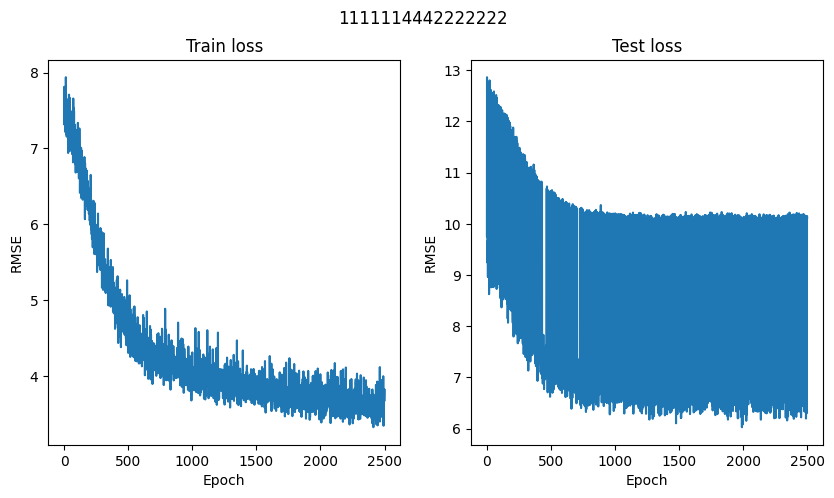

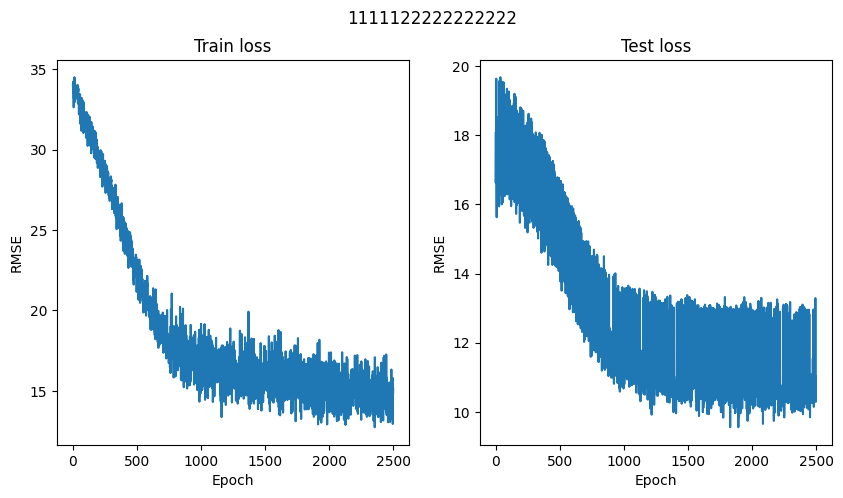

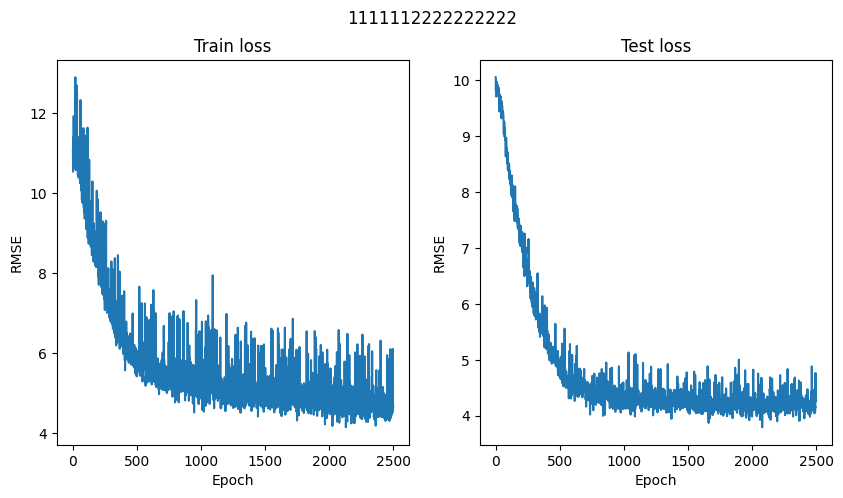

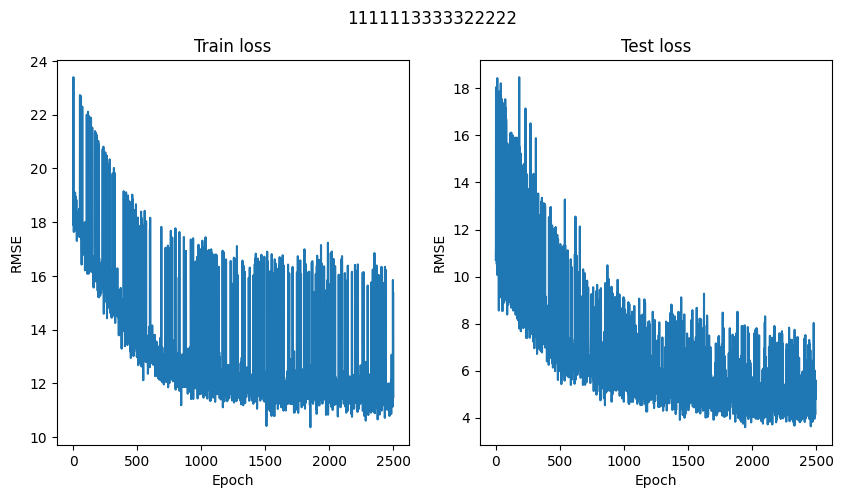

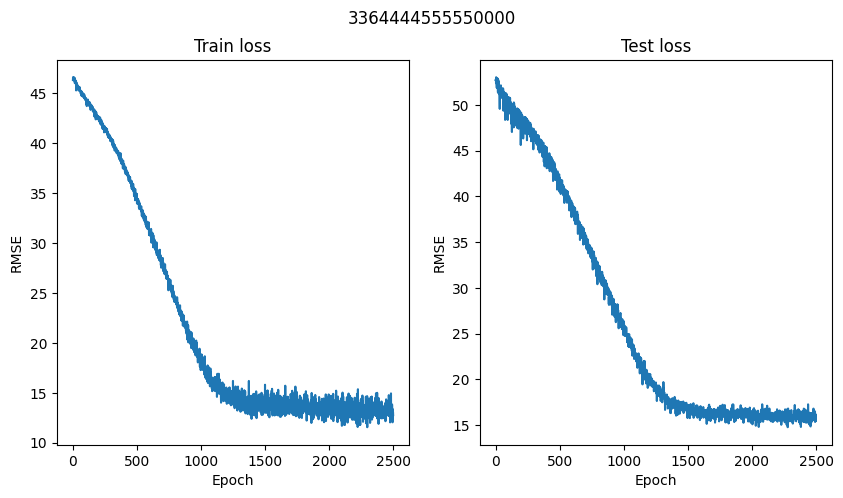

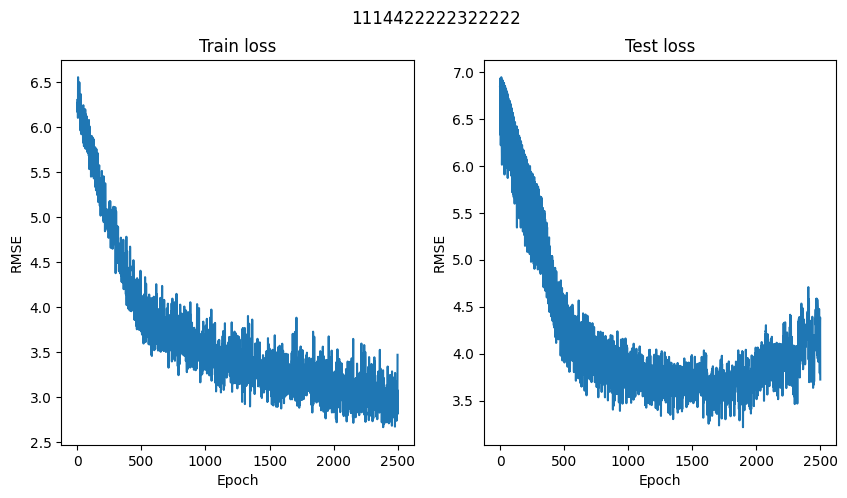

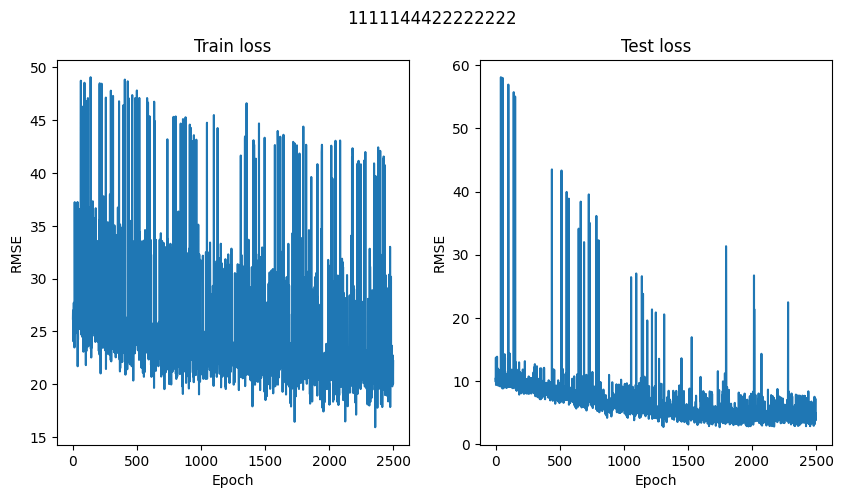

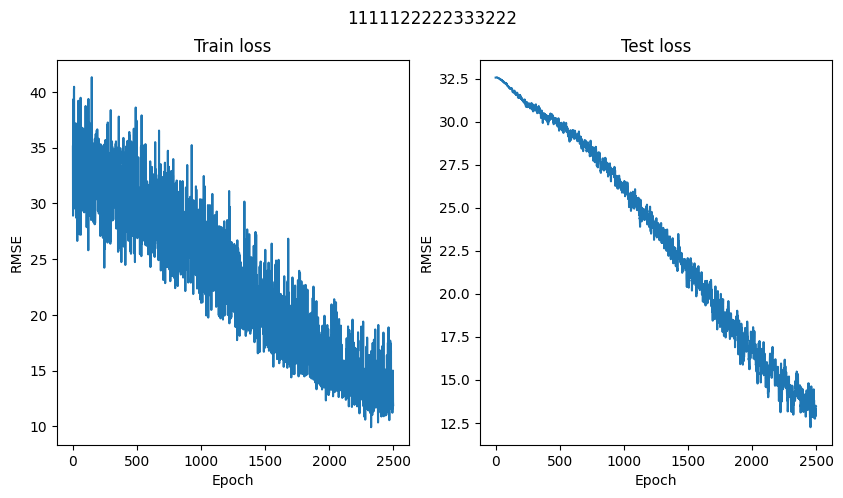

In [118]:
summary = []

os.makedirs(folder, exist_ok=True) 
writer = pd.ExcelWriter(folder+'results.xlsx',engine='xlsxwriter')  

b_size = 256

for o in range(len(data)):

    if not ((str(data[o][2]) in soil_stack)):
        continue
    
    print(data[o][1].Cycle.unique())
    # Разбиваем данные кластера на обучающую и тестовую выборки
    train, test = train_test_split(data[o][1], test_size=0.2, random_state=42, shuffle=True)

    print(test.shape)

    # Формируем обучающий и тестовый датасеты
    train_dataset = GTMDataset(train, stand=True)
    test_dataset = GTMDataset(test, stand=True)

    # Формируем загрузчики
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=b_size, shuffle=True, drop_last=False)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=b_size, shuffle=True,  drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер
    model = NeuralNet().to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr= 0.00008, weight_decay=1e-2) # 1e-3

    # Количество эпох обучения
    n_epochs = 2500

    train_loss_epoch_mean = []
    test_loss_epoch_mean = []


    # for i, (x, y, _) in enumerate(train_dataloader):
    #         print(f"Input shape: {x.shape}")  # Проверьте размер входных данных
    #         # pred = model(x)


    best_test_loss= 2500
    for epoch in tqdm.tqdm(range(n_epochs)):

        # Обучение
        train_loss = 0
        model.train()

        


        for i, (x, y, _) in enumerate(train_dataloader):

            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad()

            pred = model(x)
            loss = torch.sqrt(loss_fn(pred, y))

            loss.backward()
            optimizer.step()

            train_loss += loss.detach().cpu().numpy()

        train_loss_epoch_mean.append(train_loss/(i+1))

        # Тест
        test_loss = 0
        model.eval()
        with torch.no_grad():
            for j, (x, y, _) in enumerate(test_dataloader):

                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

                pred = model(x)

                # print(pred)
                loss = torch.sqrt(loss_fn(pred, y)) 
                test_loss += loss.detach().cpu().numpy()
        
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model = model
            best_epoch = epoch


        test_loss_epoch_mean.append(test_loss/(j+1))

    # График лосс-функции обучения и теста
    figure, axis = plt.subplots(1, 2, figsize=(10, 5))
    axis[0].plot(train_loss_epoch_mean)
    axis[0].set_title('Train loss')
    axis[0].set(xlabel='Epoch', ylabel='RMSE')
    axis[1].plot(test_loss_epoch_mean)
    axis[1].set_title('Test loss')
    axis[1].set(xlabel='Epoch', ylabel='RMSE')
    figure.suptitle(str(data[o][2]))

    figure.savefig(folder+str(data[o][0])+'_'+str(data[o][2])+'.png')

    # Расчёт метрик

    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    best_model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):
            
            x= x.to(device, non_blocking=True)

            pred = best_model(x)
            pred = pred.cpu()

            loss_rmse = torch.sqrt(loss_fn(pred, y))

            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data[o][2]), index=False)

    torch.save(best_model.state_dict(), folder + str(data[o][2]) + '.pt')

    print(str(o+1) + '.')
    print("Best epoch: ", best_epoch)
    print('DM = %i' %data[o][1]['Mark_num'].unique().shape[0])
    print('Rows = %i' %data[o][1].shape[0])
    print('Train rows = %i' %train.shape[0])
    print('Test rows = %i' %test.shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data[o][2]), data[o][1]['Mark_num'].unique().shape[0], data[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'summary.xlsx')
writer._save()

## Прогнозы


In [1]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])

for o in range(len(data11)):

    # Делаем прогноз только для тех кластеров, для которых есть обученная модель и для которых есть значения для 11-го цикла
    if not ((str(data11[o][2]) in soil_stack)):
        continue


    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset12(data11[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder+str(data11[o][2])+'.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data11[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('DM = %i' %data11[o][1][data11[o][1]['Cycle']=='XI']['Mark_num'].unique().shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data11[o][2]), data11[o][1].Mark_num.unique().shape[0], data11[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary_11.xlsx')
writer._save()

NameError: name 'pd' is not defined

In [30]:
data11[2][1][data11[2][1]['Cycle']=='XI']['Mark_num'].unique().shape[0]

77

In [120]:
data11[2][1].shape[0]

211

In [121]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])

for o in range(len(data12)):

    # Делаем прогноз только для тех кластеров, для которых есть обученная модель и для которых есть значения для 11-го цикла
    if not ((str(data12[o][2]) in soil_stack)):
        continue


    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset12(data12[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder+str(data12[o][2])+'.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data12[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('DM = %i' %data12[o][1][data12[o][1]['Cycle']=='XII']['Mark_num'].unique().shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data12[o][2]), data12[o][1][data12[o][1]['Cycle']=='XII']['Mark_num'].unique().shape[0], data12[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary_12.xlsx')
writer._save()

327 327
4.
DM = 327
R2 = 0.50
RMSE = 4.40
MAE = 3.31


529 529
30.
DM = 529
R2 = 0.77
RMSE = 21.19
MAE = 9.88


392 392
33.
DM = 392
R2 = 0.22
RMSE = 30.89
MAE = 5.41


259 259
38.
DM = 259
R2 = 0.22
RMSE = 16.73
MAE = 6.05


430 430
43.
DM = 430
R2 = 0.79
RMSE = 19.51
MAE = 9.36


302 302
44.
DM = 302
R2 = -0.08
RMSE = 16.17
MAE = 6.76


228 228
92.
DM = 228
R2 = 0.70
RMSE = 17.90
MAE = 6.22


103 103
165.
DM = 103
R2 = 0.17
RMSE = 26.77
MAE = 17.95




In [122]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])

for o in range(len(data1112)):

    # Делаем прогноз только для тех кластеров, для которых есть обученная модель и для которых есть значения для 11-го цикла
    if not ((str(data1112[o][2]) in soil_stack)):
        continue


    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset12(data1112[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder+str(data1112[o][2])+'.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data1112[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('DM = %i' %data1112[o][1][data1112[o][1]['Cycle']=='XII']['Mark_num'].unique().shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data1112[o][2]),
                    data1112[o][1].Mark_num.unique().shape[0], 
                    data1112[o][1].shape[0],
                    res_r2, 
                    res_rmse, 
                    res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary_1112.xlsx')
writer._save()

327 654
4.
DM = 327
R2 = 0.45
RMSE = 4.48
MAE = 3.16


573 1094
30.
DM = 529
R2 = 0.60
RMSE = 15.74
MAE = 7.32


409 801
33.
DM = 392
R2 = 0.32
RMSE = 22.30
MAE = 4.59


274 518
38.
DM = 259
R2 = 0.37
RMSE = 12.80
MAE = 5.14


486 833
43.
DM = 430
R2 = 0.78
RMSE = 19.47
MAE = 9.35


357 636
44.
DM = 302
R2 = 0.09
RMSE = 11.39
MAE = 4.48


228 456
92.
DM = 228
R2 = 0.27
RMSE = 27.63
MAE = 6.17


117 220
165.
DM = 103
R2 = -0.21
RMSE = 29.55
MAE = 18.57




In [36]:
data1112[14][1][data1112[14][1]['Cycle']=='XII']

,Site,Участок,Mark_num,Mark_name,di,di-1,di-2,di-3,di-4,Cycle,...,SoilType_3,SoilType_35,SoilType_4,SoilType_45,SoilType_5,SoilType_6,SoilType_7,SoilType_8,SoilType_9,SoilType_10
10843,ГТМ.025,ГТМ.025.01,ДМ.015628,24.3,6.8,0.667752,0.878878,1.222355,1.546723,XII,...,5,5,5,5,0,0,0,0,0,0
10844,ГТМ.025,ГТМ.025.01,ДМ.015629,24.4,5.5,0.612858,0.951468,0.893625,1.343383,XII,...,5,5,5,5,0,0,0,0,0,0
10845,ГТМ.025,ГТМ.025.01,ДМ.015630,24.5,-4.7,-0.419146,-0.379361,-0.037775,0.373606,XII,...,5,5,5,5,0,0,0,0,0,0
10846,ГТМ.025,ГТМ.025.01,ДМ.015631,24.6,-6.8,-0.320337,-0.113195,0.153984,0.764645,XII,...,5,5,5,5,0,0,0,0,0,0
10849,ГТМ.025,ГТМ.025.01,ДМ.015624,skv24-6,8.8,1.414307,-0.935890,1.537387,-1.065419,XII,...,5,5,5,5,0,0,0,0,0,0


# ТЕМПЕРАТУРЫ

## Библиотеки и гиперпараметры

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils
import torch.utils.data

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import tqdm

import math



In [58]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# DEPTH = 6
depths = [6,7,8,9,10]
ROOT_DIR = '.\\data\\tests__hypotesys\\'
folder = f'.\\data\\tests__hypotesys\\Results_4\\'

num_exp = 4

In [69]:
class NeuralNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(62,32),
            # nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32,16),
            nn.ReLU(),

            nn.Linear(16,8),
            nn.ReLU(),
            
            nn.Linear(8,1)
        )

    def forward(self, x):
        return self.net(x)


In [66]:
class GTMDataset(torch.utils.data.Dataset):

    def __init__(self, data, stand=True):

        # Имена колонок для входного вектора
        # other_columns = [
        #     'temp_7_1', 'temp_7_2', 'temp_7_3', 'temp_7_4',
        #     'temp_6_1', 'temp_8_1', 'temp_9_1', 'temp_10_1',
        #     'temp_6_2', 'temp_8_2', 'temp_9_2', 'temp_10_2',
        #     'temp_6_3', 'temp_8_3', 'temp_9_3', 'temp_10_3',
        #     'temp_6_4', 'temp_8_4', 'temp_9_4', 'temp_10_4',
        #     # 'tai_1', 'tai_2', 'tai_3',  
        #     'snowi','snowi_1', 'snowi_2', 'snowi_3', 
        #     'preci','preci_1', 'preci_2', 'preci_3', 
        #     'tempi','tempi_1', 'tempi_2', 'tempi_3',
        #     'Swamp'
        #     ]
        other_columns = [
            'temp_7_1', 'temp_7_2', 'temp_7_3',
            'temp_6_1', 'temp_8_1', 'temp_9_1', 'temp_10_1',
            'temp_6_2', 'temp_8_2', 'temp_9_2', 'temp_10_2',
            'temp_6_3', 'temp_8_3', 'temp_9_3', 'temp_10_3',
            # 'tai_1', 'tai_2', 'tai_3',  
            'snowi','snowi_1', 'snowi_2', 
            'preci','preci_1', 'preci_2',  
            'tempi','tempi_1', 'tempi_2',
            'Swamp'
            ]
        
         # Имена колонок для входного вектора с информацией о типе почвы и температуре на 5-и глубинах
        soil_type_columns = ['SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']

        # Добавляем в датасет 7 фиктивных строк
        # Для каждой колонки с информацией о типе почвы на определённой глубине добавляем все 7 возможных типов почв
        # В этом случае one-hot кодирование типов почв отработает одинаково для всех колонок.
        data = pd.concat([data, data.iloc[-7:,:]])

        for column in range(data.columns.get_loc('SoilType_0'),data.columns.get_loc('SoilType_10')+1):
            data.iloc[-7:,column:column+1] = pd.DataFrame(np.arange(7))

        data.iloc[-3,data.columns.get_loc('Swamp')] = 2
        data.iloc[-2,data.columns.get_loc('Swamp')] = 1
        data.iloc[-1,data.columns.get_loc('Swamp')] = 0

        # Собираем набор входных векторов и соответсвующий набор значений целевого параметра
        X = data[[ *other_columns, *soil_type_columns]]
        y = data['temp_i']
        self.z = data[['TS_num', 'Cycle', 'depth']].to_numpy().tolist()


        # Выполняем one-hot кодирование Swamp
        X = pd.get_dummies(X, columns=['Swamp'], dtype=float)

        # Выполняем one-hot кодирование типов почв
        X = pd.get_dummies(X, columns=soil_type_columns, dtype=float)

        # Удаляем фиктивные строки
        X = X.iloc[:-7]
        y = y.iloc[:-7]
        self.z = self.z[:-7]

      
        # Формируем тензоры
        self.X = torch.tensor(X.values.astype(float), dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).reshape(-1,1)

    
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.z[i]

In [67]:
class GTMDataset_check(torch.utils.data.Dataset):

    def __init__(self, data, stand=True):

        # Имена колонок для входного вектора
        # other_columns = [
        #     'temp_7_1', 'temp_7_2', 'temp_7_3', 'temp_7_4',
        #     'temp_6_1', 'temp_8_1', 'temp_9_1', 'temp_10_1',
        #     'temp_6_2', 'temp_8_2', 'temp_9_2', 'temp_10_2',
        #     'temp_6_3', 'temp_8_3', 'temp_9_3', 'temp_10_3',
        #     'temp_6_4', 'temp_8_4', 'temp_9_4', 'temp_10_4',
        #     # 'tai_1', 'tai_2', 'tai_3',  
        #     'snowi','snowi_1', 'snowi_2', 'snowi_3', 
        #     'preci','preci_1', 'preci_2', 'preci_3', 
        #     'tempi','tempi_1', 'tempi_2', 'tempi_3',
        #     'Swamp'
        #     ]

        other_columns = [
            'temp_7_1', 'temp_7_2', 'temp_7_3',
            'temp_6_1', 'temp_8_1', 'temp_9_1', 'temp_10_1',
            'temp_6_2', 'temp_8_2', 'temp_9_2', 'temp_10_2',
            'temp_6_3', 'temp_8_3', 'temp_9_3', 'temp_10_3',
            # 'tai_1', 'tai_2', 'tai_3',  
            'snowi','snowi_1', 'snowi_2', 
            'preci','preci_1', 'preci_2',  
            'tempi','tempi_1', 'tempi_2',
            'Swamp'
            ]
        # other_columns = [
        #     'temp_6_1', 'temp_6_2', 'temp_6_3',
        #     'temp_7_1', 'temp_8_1', 'temp_9_1', 'temp_10_1',
        #     'temp_7_2', 'temp_8_2', 'temp_9_2', 'temp_10_2',
        #     'temp_7_3', 'temp_8_3', 'temp_9_3', 'temp_10_3',
        #     'tai_1', 'tai_2', 'tai_3',  
        #     'snowi_1','snowi_2', 'snowi_3', 
        #     'preci_1','preci_2', 'preci_3',  
        #     'tempi_1','tempi_2', 'tempi_3',
        #     'Swamp'
        #     ]
        
         # Имена колонок для входного вектора с информацией о типе почвы и температуре на 5-и глубинах
        soil_type_columns = ['SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']

        # Добавляем в датасет 7 фиктивных строк
        # Для каждой колонки с информацией о типе почвы на определённой глубине добавляем все 7 возможных типов почв
        # В этом случае one-hot кодирование типов почв отработает одинаково для всех колонок.
        data = pd.concat([data, data.iloc[-7:,:]])

        for column in range(data.columns.get_loc('SoilType_0'),data.columns.get_loc('SoilType_10')+1):
            data.iloc[-7:,column:column+1] = pd.DataFrame(np.arange(7))

        data.iloc[-3,data.columns.get_loc('Swamp')] = 2
        data.iloc[-2,data.columns.get_loc('Swamp')] = 1
        data.iloc[-1,data.columns.get_loc('Swamp')] = 0

        # Собираем набор входных векторов и соответсвующий набор значений целевого параметра
        X = data[[ *other_columns, *soil_type_columns, 'TS_num', 'Cycle', 'depth']]
        y = data[['temp_i', 'TS_num', 'Cycle', 'depth']]
        self.z = data[['TS_num', 'Cycle', 'depth']].to_numpy().tolist()


        # Выполняем one-hot кодирование Swamp
        X = pd.get_dummies(X, columns=['Swamp'], dtype=float)

        # Выполняем one-hot кодирование типов почв
        X = pd.get_dummies(X, columns=soil_type_columns, dtype=float)

        # Удаляем фиктивные строки
        X = X.iloc[:-7]
        y = y.iloc[:-7]
        self.z = self.z[:-7]

        print(X.columns)
        self.X = X
        self.y = y
        # Формируем тензоры
        # self.X = torch.tensor(X.values.astype(float), dtype=torch.float32)
        # self.y = torch.tensor(y.values, dtype=torch.float32).reshape(-1,1)

    
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.z[i]

## Инициализация данных

In [62]:
def prepare_data():

    res=[]
    for d in depths:
        # Загружаем данные для обработки
        data = pd.read_csv(f'{ROOT_DIR}data{num_exp}_cycle_{d}_scaled.csv')
        data = data[data.Cycle != 'XII']
        data = data[data.Cycle != 'XI']

        # data\data_tmp\data_cycle_6_scaled.csv

        
        res.append((d, data, 0))

    return res

def prepare_data11():
    res=[]
    for d in depths:

        # Загружаем данные для обработки
        data = pd.read_csv(f'{ROOT_DIR}data{num_exp}_cycle_{d}_scaled.csv')
        data = data[data.Cycle == 'XI']
    
        res.append((d, data, 0))

    return res

def prepare_data12():
    res=[]
    for d in depths:

        # Загружаем данные для обработки
        data = pd.read_csv(f'{ROOT_DIR}data{num_exp}_cycle_{d}_scaled.csv')
        data = data[data.Cycle == 'XII']
    
        res.append((d, data, 0))

    return res

def prepare_data1112():

    res=[]
    for d in depths:
        # Загружаем данные для обработки
        data = pd.read_csv(f'{ROOT_DIR}data{num_exp}_cycle_{d}_scaled.csv')
        data = data[(data['Cycle'] == 'XI') | (data['Cycle'] == 'XII')] 

        
        res.append((d, data, 0))

    return res

data = prepare_data()
data11 = prepare_data11()
data12 = prepare_data12()
data1112 = prepare_data1112()

<Axes: >

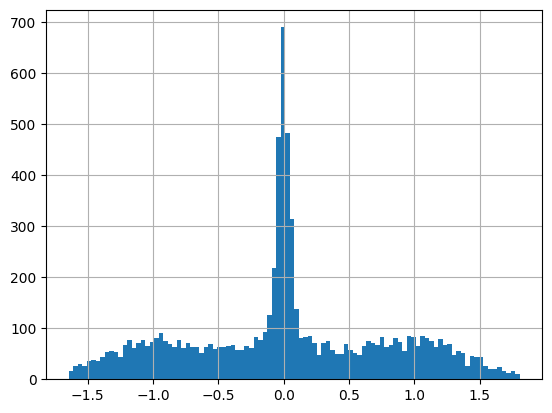

In [63]:
data[4][1].temp_6_1.hist(bins=100)

## Обучение

  0%|          | 0/600 [00:00<?, ?it/s]

100%|██████████| 600/600 [02:12<00:00,  4.52it/s]


Глубина 6.
Best epoch:  450
TS = 1057
Rows = 6120
Train rows = 5508
Test rows = 612
R2 = 0.92
RMSE = 0.43
MAE = 0.27




100%|██████████| 600/600 [02:51<00:00,  3.49it/s]


Глубина 7.
Best epoch:  249
TS = 1182
Rows = 7870
Train rows = 7083
Test rows = 787
R2 = 0.81
RMSE = 0.37
MAE = 0.24




...

Глубина 8.
Best epoch:  295
TS = 1190
Rows = 7896
Train rows = 7106
Test rows = 790
R2 = 0.70
RMSE = 0.28
MAE = 0.19




100%|██████████| 600/600 [02:52<00:00,  3.47it/s]


Глубина 9.
Best epoch:  179
TS = 1212
Rows = 7919
Train rows = 7127
Test rows = 792
R2 = 0.45
RMSE = 0.24
MAE = 0.16




100%|██████████| 600/600 [02:48<00:00,  3.56it/s]


Глубина 10.
Best epoch:  194
TS = 1212
Rows = 7919
Train rows = 7127
Test rows = 792
R2 = 0.19
RMSE = 0.20
MAE = 0.14




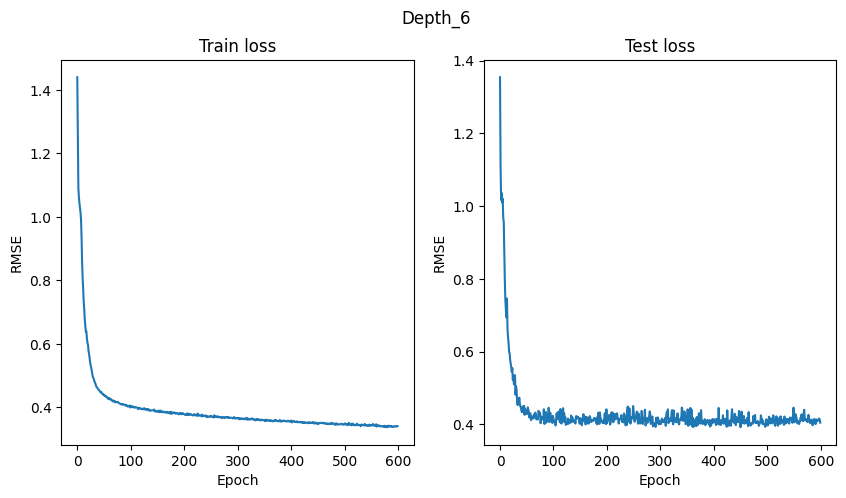

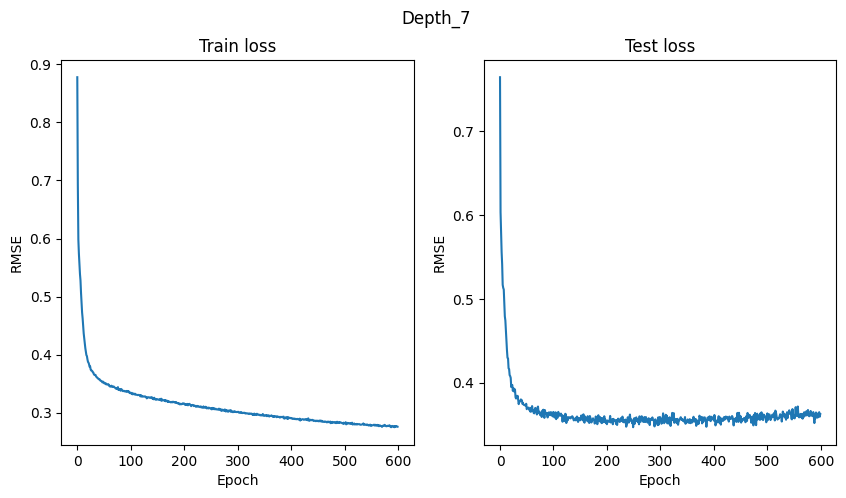

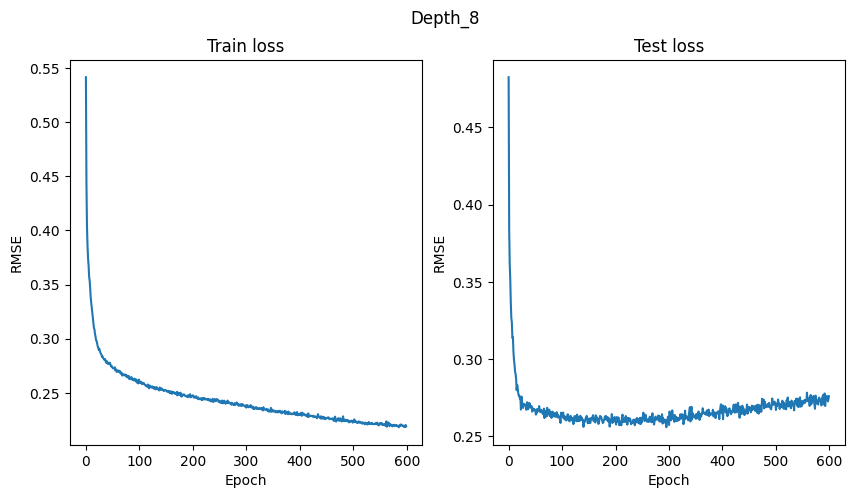

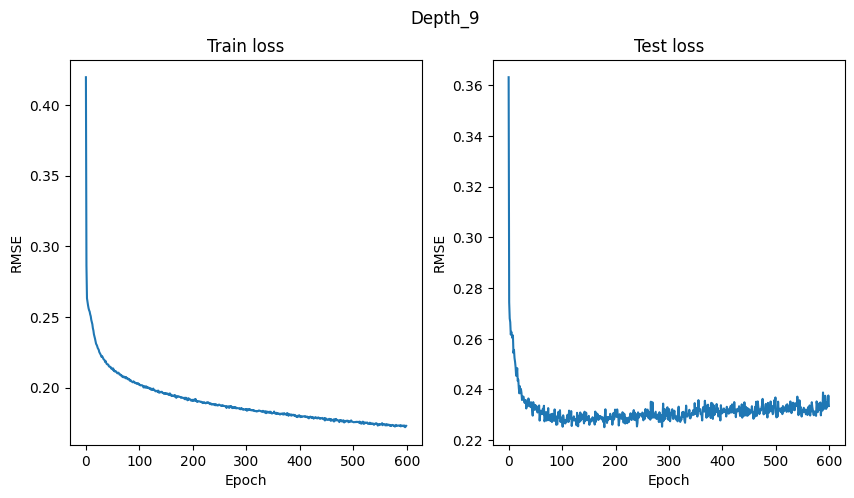

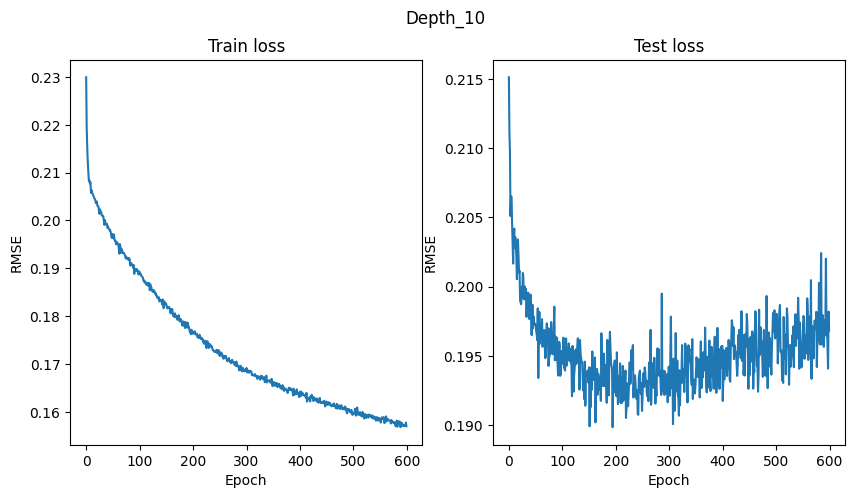

In [70]:
summary = []
# Обучаем модель на 4-10 циклах
os.makedirs(folder, exist_ok=True) 
writer = pd.ExcelWriter('results.xlsx',engine='xlsxwriter')  
b_size = 32



for o in range(len(data)):
    

    # if data[o][0] in [6]:
    #     continue


    # print(data[o][1].Cycle.unique())
    # Разбиваем данные кластера на обучающую и тестовую выборки
    train, test = train_test_split(data[o][1], test_size=0.1, shuffle=True) # random_state=34

    # print(test.shape)

    # Формируем обучающий и тестовый датасеты
    train_dataset = GTMDataset(train, stand=True)
    test_dataset = GTMDataset(test, stand=True)

    # Формируем загрузчики
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=b_size, shuffle=True, drop_last=False)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=b_size, shuffle=True,  drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер
    model = NeuralNet().to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr= 0.0001, weight_decay=1e-3) # 1e-3

    # Количество эпох обучения
    n_epochs = 600

    train_loss_epoch_mean = []
    test_loss_epoch_mean = []


    # for i, (x, y, _) in enumerate(train_dataloader):
    #         print(f"Input shape: {x.shape}")  # Проверьте размер входных данных
    #         # pred = model(x)


    best_test_loss= 2500
    for epoch in tqdm.tqdm(range(n_epochs)):

        # Обучение
        train_loss = 0
        model.train()

        


        for i, (x, y, _) in enumerate(train_dataloader):

            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad()

            pred = model(x)
            loss = torch.sqrt(loss_fn(pred, y))

            loss.backward()
            optimizer.step()

            train_loss += loss.detach().cpu().numpy()

        train_loss_epoch_mean.append(train_loss/(i+1))

        # Тест
        test_loss = 0
        model.eval()
        with torch.no_grad():
            for j, (x, y, _) in enumerate(test_dataloader):

                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

                pred = model(x)

                # print(pred)
                loss = torch.sqrt(loss_fn(pred, y)) 
                test_loss += loss.detach().cpu().numpy()
        
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model = model
            best_epoch = epoch


        test_loss_epoch_mean.append(test_loss/(j+1))

    # График лосс-функции обучения и теста
    figure, axis = plt.subplots(1, 2, figsize=(10, 5))
    axis[0].plot(train_loss_epoch_mean)
    axis[0].set_title('Train loss')
    axis[0].set(xlabel='Epoch', ylabel='RMSE')
    axis[1].plot(test_loss_epoch_mean)
    axis[1].set_title('Test loss')
    axis[1].set(xlabel='Epoch', ylabel='RMSE')
    figure.suptitle(f'Depth_{data[o][0]}')

    figure.savefig(folder+f'Depth_{data[o][0]}'+'.png')

    # Расчёт метрик

    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    best_model.eval()

    rmse = []
    mae = []
    r2 = []

    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):
            
            x= x.to(device, non_blocking=True)

            pred = best_model(x)
            pred = pred.cpu()

            loss_rmse = torch.sqrt(loss_fn(pred, y))

            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer, index=False)

    torch.save(best_model.state_dict(), folder + f'depth_{data[o][0]}' + '.pt')

    print(f'Глубина {data[o][0]}' + '.')
    print("Best epoch: ", best_epoch)
    print('TS = %i' %data[o][1]['TS_num'].unique().shape[0])
    print('Rows = %i' %data[o][1].shape[0])
    print('Train rows = %i' %train.shape[0])
    print('Test rows = %i' %test.shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([data[o][0], data[o][1]['TS_num'].unique().shape[0], data[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Depth', 'TS', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'summary.xlsx')
writer._save()

# Прогноз 11 цикл

In [55]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])



for o in range(len(data11)):

    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset(data11[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder + f'depth_{data11[o][0]}' + '.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []

    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data11[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([data11[o][0], data[o][1]['TS_num'].unique().shape[0], data11[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Depth','TS', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary11.xlsx')
writer._save()

1.
R2 = 0.86
RMSE = 0.32
MAE = 0.19


2.
R2 = 0.76
RMSE = 0.31
MAE = 0.22


3.
R2 = 0.73
RMSE = 0.19
MAE = 0.12


4.
R2 = 0.53
RMSE = 0.15
MAE = 0.10


5.
R2 = -0.15
RMSE = 0.18
MAE = 0.13




# Прогноз 12 цикл

In [56]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])



for o in range(len(data12)):

    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset(data12[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder + f'depth_{data12[o][0]}' + '.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []

    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data12[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([data12[o][0], data[o][1]['TS_num'].unique().shape[0], data12[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Depth','TS', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary12.xlsx')
writer._save()

1.
R2 = 0.56
RMSE = 0.75
MAE = 0.63


2.
R2 = 0.40
RMSE = 0.57
MAE = 0.44


3.
R2 = 0.22
RMSE = 0.40
MAE = 0.30


4.
R2 = -0.18
RMSE = 0.29
MAE = 0.20


5.
R2 = -0.51
RMSE = 0.21
MAE = 0.14




# Прогноз 11 - 12 цикл

In [57]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])



for o in range(len(data1112)):

    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset(data1112[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder + f'depth_{data1112[o][0]}' + '.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []

    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data1112[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([data1112[o][0], data[o][1]['TS_num'].unique().shape[0], data1112[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Depth','TS', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary1112.xlsx')
writer._save()

1.
R2 = 0.86
RMSE = 0.57
MAE = 0.41


2.
R2 = 0.77
RMSE = 0.45
MAE = 0.32


3.
R2 = 0.63
RMSE = 0.31
MAE = 0.21


4.
R2 = 0.24
RMSE = 0.24
MAE = 0.16


5.
R2 = -0.57
RMSE = 0.26
MAE = 0.21


